In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os

project_path = '/content/drive/MyDrive/Image project /dataset-balls-20260507T135657Z-3-001/dataset-balls'

# Check if the path exists
if os.path.exists(project_path):
    print(f"Contents of '{project_path}':")
    for item in os.listdir(project_path):
        print(item)
else:
    print(f"The specified path '{project_path}' does not exist. Please check the path and try again.")

Contents of '/content/drive/MyDrive/Image project /dataset-balls-20260507T135657Z-3-001/dataset-balls':
test
train


In [3]:
import os

train_path = os.path.join(project_path, 'train')
test_path = os.path.join(project_path, 'test')

print(f"\nContents of the 'train' directory ({train_path}):")
if os.path.exists(train_path):
    for item in os.listdir(train_path):
        print(item)
else:
    print(f"The 'train' directory '{train_path}' does not exist.")

print(f"\nContents of the 'test' directory ({test_path}):")
if os.path.exists(test_path):
    for item in os.listdir(test_path):
        print(item)
else:
    print(f"The 'test' directory '{test_path}' does not exist.")


Contents of the 'train' directory (/content/drive/MyDrive/Image project /dataset-balls-20260507T135657Z-3-001/dataset-balls/train):
baseball
football
tennis_ball
golf_ball
basketball
american_football

Contents of the 'test' directory (/content/drive/MyDrive/Image project /dataset-balls-20260507T135657Z-3-001/dataset-balls/test):
football
basketball
american_football
baseball
golf_ball
tennis_ball


In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# Dataset paths
train_dir = '/content/drive/MyDrive/Image project /dataset-balls-20260507T135657Z-3-001/dataset-balls/train'
test_dir = '/content/drive/MyDrive/Image project /dataset-balls-20260507T135657Z-3-001/dataset-balls/test'

# Image settings
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Load datasets
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Print class indices
print("\nClass Labels:")
print(train_data.class_indices)

Found 1407 images belonging to 6 classes.
Found 289 images belonging to 6 classes.

Class Labels:
{'american_football': 0, 'baseball': 1, 'basketball': 2, 'football': 3, 'golf_ball': 4, 'tennis_ball': 5}


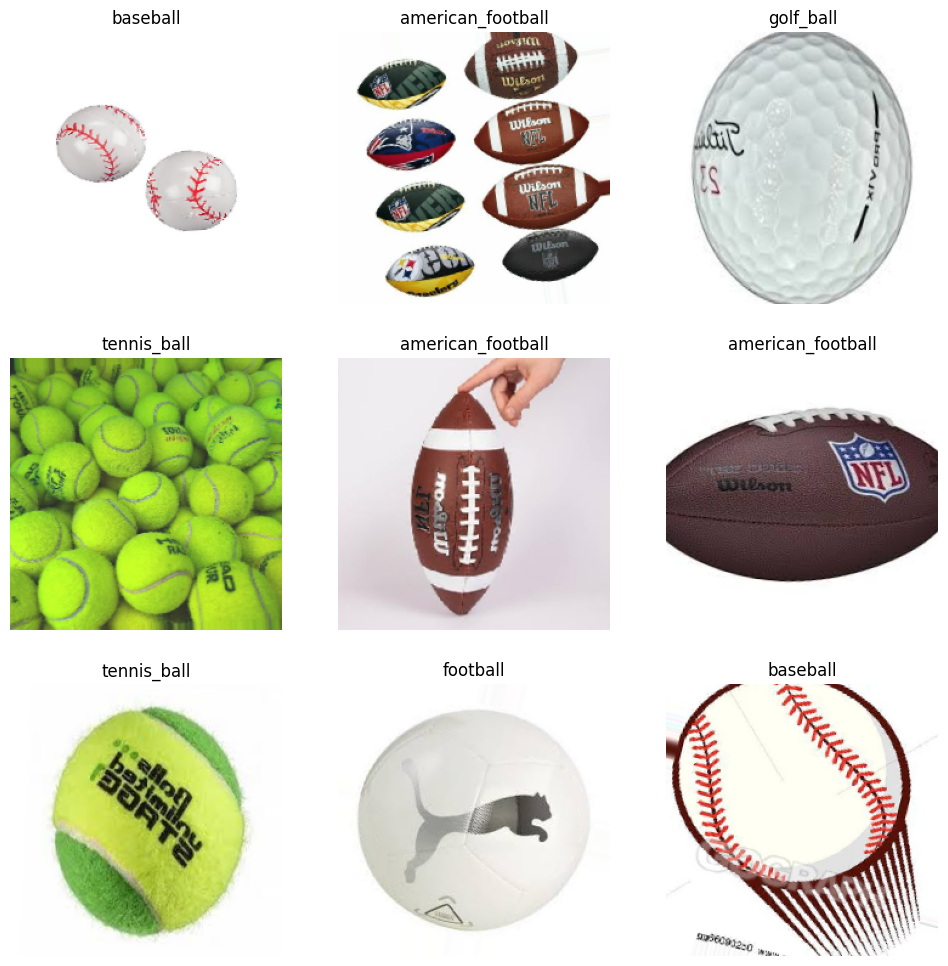

In [5]:
# Get one batch
images, labels = next(train_data)

# Plot images
plt.figure(figsize=(12, 12))

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i])

    # Convert one-hot label to class name
    class_name = list(train_data.class_indices.keys())[labels[i].argmax()]
    plt.title(class_name)

    plt.axis('off')

plt.show()

In [6]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

# Load pretrained model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained layers
base_model.trainable = False

# Build model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(6, activation='softmax')
])

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Show model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [7]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=5
)

Epoch 1/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 227s 5s/step - accuracy: 0.8728 - loss: 0.3951 - val_accuracy: 0.9862 - val_loss: 0.0414
Epoch 2/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - accuracy: 0.9709 - loss: 0.0771 - val_accuracy: 0.9862 - val_loss: 0.0474
Epoch 3/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 102s 2s/step - accuracy: 0.9844 - loss: 0.0509 - val_accuracy: 0.9931 - val_loss: 0.0332
Epoch 4/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 111s 3s/step - accuracy: 0.9943 - loss: 0.0241 - val_accuracy: 0.9931 - val_loss: 0.0381
Epoch 5/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 115s 3s/step - accuracy: 0.9936 - loss: 0.0242 - val_accuracy: 0.9862 - val_loss: 0.0354


In [8]:
# Evaluate model
test_loss, test_accuracy = model.evaluate(test_data)

print(f"\nTest Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.9862 - loss: 0.0354

Test Accuracy: 98.62%
Test Loss: 0.0354


10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step

Classification Report:

                   precision    recall  f1-score   support

american_football       0.96      0.96      0.96        50
         baseball       1.00      1.00      1.00        49
       basketball       0.96      0.96      0.96        50
         football       1.00      1.00      1.00        45
        golf_ball       1.00      1.00      1.00        45
      tennis_ball       1.00      1.00      1.00        50

         accuracy                           0.99       289
        macro avg       0.99      0.99      0.99       289
     weighted avg       0.99      0.99      0.99       289



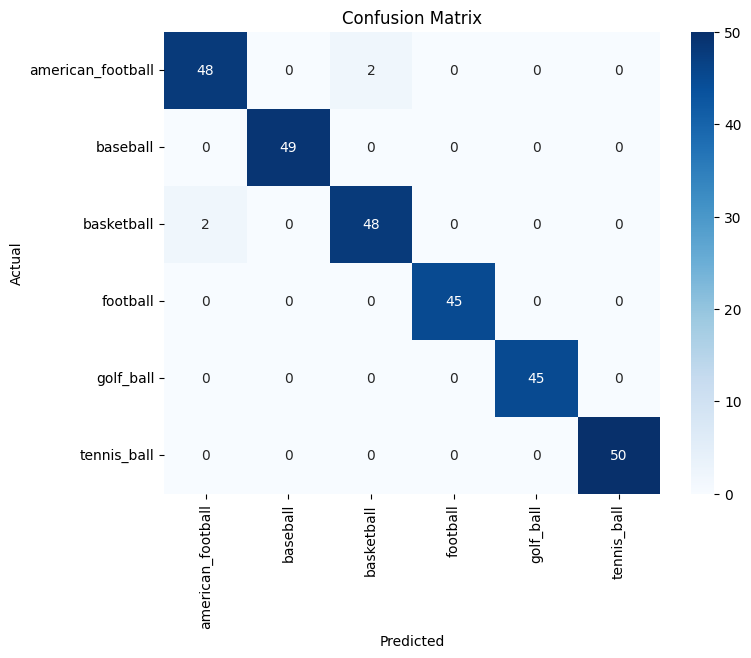

In [9]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate predictions
predictions = model.predict(test_data)

predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_data.classes

class_labels = list(test_data.class_indices.keys())

# Classification report
print("\nClassification Report:\n")
print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels
))

# Confusion Matrix
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

In [10]:
model.save('/content/drive/MyDrive/ball_classifier_model.h5')

print("Model saved successfully!")

Model saved successfully!


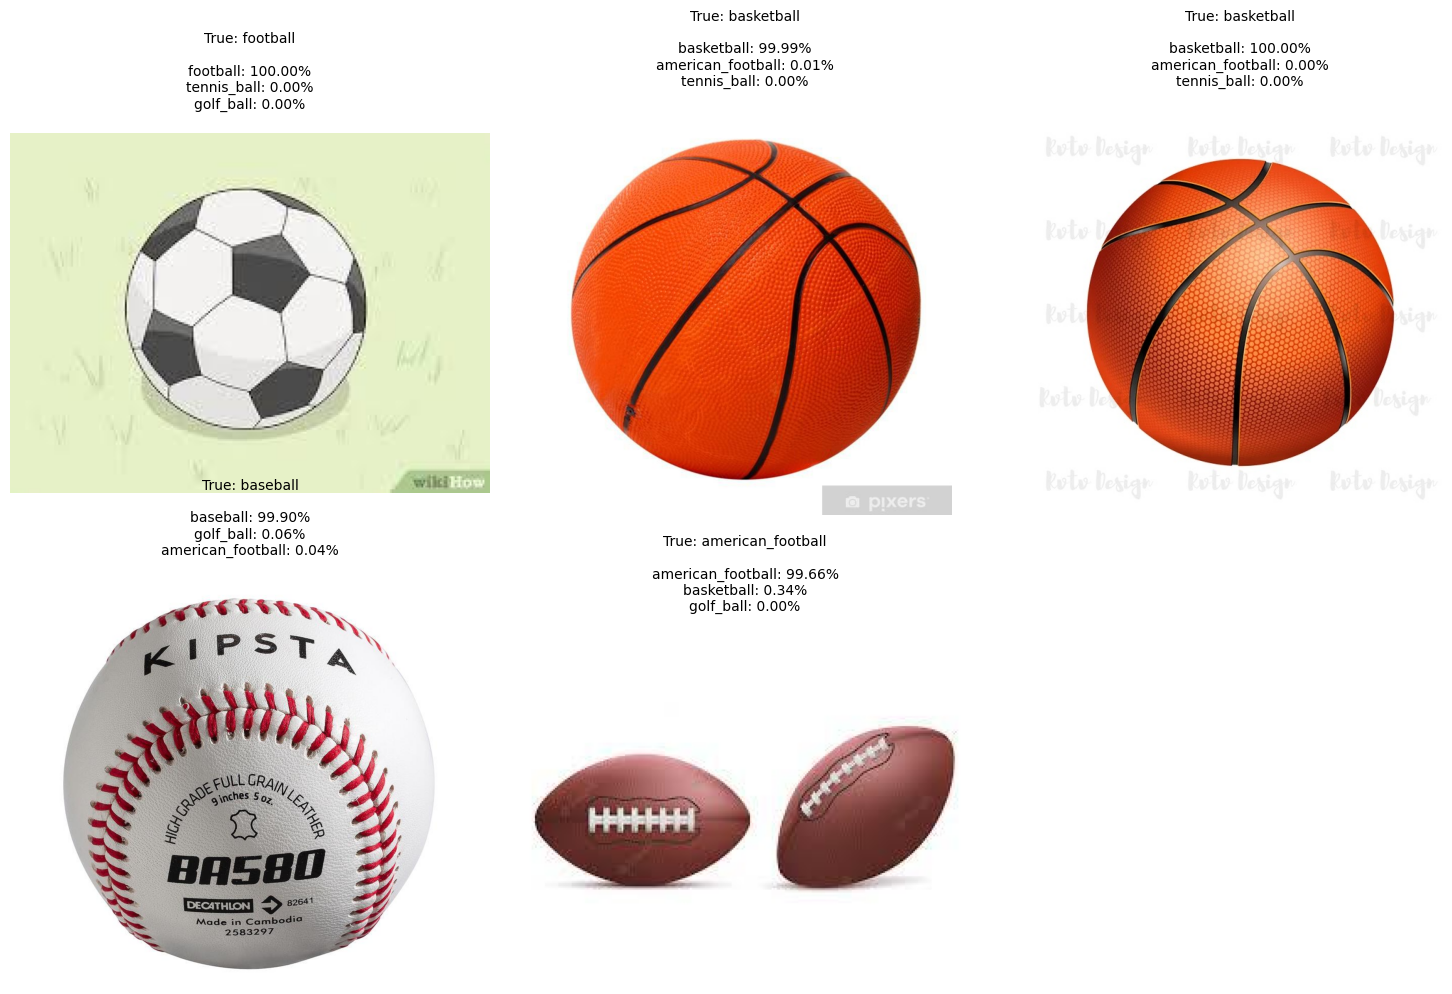

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import random
import os

# Class names
class_names = [
    'american_football',
    'baseball',
    'basketball',
    'football',
    'golf_ball',
    'tennis_ball'
]

# Path to test dataset
test_dir = '/content/drive/MyDrive/Image project /dataset-balls-20260507T135657Z-3-001/dataset-balls/test'

# Collect all test image paths
all_images = []

for class_name in class_names:
    class_path = os.path.join(test_dir, class_name)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        all_images.append((img_path, class_name))

# Randomly choose 5 test images
sample_images = random.sample(all_images, 5)

# Display predictions
plt.figure(figsize=(15,10))

for i, (img_path, true_label) in enumerate(sample_images):

    # Load image
    img = image.load_img(img_path, target_size=(224, 224))

    # Convert to array
    img_array = image.img_to_array(img)

    # Normalize
    img_array = img_array / 255.0

    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    prediction = model.predict(img_array, verbose=0)[0]

    # Get top 3 predictions
    top3_indices = prediction.argsort()[-3:][::-1]

    # Create title text
    title_text = f"True: {true_label}\n\n"

    for idx in top3_indices:
        title_text += f"{class_names[idx]}: {prediction[idx]*100:.2f}%\n"

    # Plot image
    plt.subplot(2,3,i+1)
    plt.imshow(image.load_img(img_path))
    plt.title(title_text, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()